# ¿El miedo te rompe el sueño? Lo que se ve en ratones

Le das un susto a un ratón. Cuando se duerme, su sueño se parte en más pedazos: **+37 micro-despertares, un 22% más**. Y no fue casualidad de un animal — los **7** ratones reaccionaron igual.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *Memory reactivation underlies experience-dependent adaptive regulation of sleep*
*Science* (2026) · [DOI: 10.1126/science.aed8630](https://doi.org/10.1126/science.aed8630)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-04-reactivacion-memoria-sueno/notebook.ipynb)

**Video:** Pendiente

## Qué hicieron

Registraron el sueño de los ratones **antes y después** de una experiencia de miedo: el condicionamiento de miedo contextual (CFC), un protocolo estándar donde el animal aprende a asociar un lugar con una descarga leve.

La pregunta era simple: ¿una mala experiencia cambia la *estructura* del sueño que viene después? Para medirlo contaron los **episodios de vigilia y micro-despertar** (Wake/MA) durante el registro: cuántas veces el sueño se interrumpe. Más episodios = sueño más fragmentado.

Un grupo Control pasó por el mismo registro, sin el miedo.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
ETAPA = 'Wake/MA'            # 'Wake/MA', 'NREM' o 'REM'
COLOR_MIEDO = '#DC2626'      # grupo del miedo (CFC)
COLOR_CONTROL = '#BBBBBB'    # grupo Control
COLOR_NEUTRO = '#2563EB'     # acentos
FUENTE = ('Fuente: Yu et al. (2026), Science | '
          'Datos: Zenodo 10.5281/zenodo.18733745')

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo CaM (local -> fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

df = pd.read_csv('datos/fig1c_episodios_sueno.csv')

def serie(grupo, fase, etapa):
    sub = df[(df.grupo == grupo) & (df.fase == fase) & (df.etapa == etapa)]
    return sub.sort_values('animal_id')['episodios'].to_numpy(dtype=float)

# Resumen del hero (Wake/MA)
cfc_pre = serie('CFC', 'Pre', ETAPA)
cfc_post = serie('CFC', 'Post', ETAPA)
ctl_pre = serie('Control', 'Pre', ETAPA)
ctl_post = serie('Control', 'Post', ETAPA)

diffs_cfc = cfc_post - cfc_pre
diffs_ctl = ctl_post - ctl_pre

d_pareado = diffs_cfc.mean() / diffs_cfc.std(ddof=1)
w_cfc = stats.wilcoxon(cfc_post, cfc_pre)
w_ctl = stats.wilcoxon(ctl_post, ctl_pre)

print(f'Etapa analizada: {ETAPA}')
print(f'MIEDO (CFC)  n={len(cfc_pre)}: {cfc_pre.mean():.1f} -> {cfc_post.mean():.1f} '
      f'episodios  (Δ {diffs_cfc.mean():+.1f}, {100*diffs_cfc.mean()/cfc_pre.mean():+.1f}%)')
print(f'   d pareado = {d_pareado:.2f}  |  Wilcoxon p = {w_cfc.pvalue:.4f}  |  '
      f'subieron {(diffs_cfc>0).sum()}/{len(diffs_cfc)}')
print(f'CONTROL      n={len(ctl_pre)}: {ctl_pre.mean():.1f} -> {ctl_post.mean():.1f} '
      f'episodios  (Δ {diffs_ctl.mean():+.1f}, {100*diffs_ctl.mean()/ctl_pre.mean():+.1f}%)')
print(f'   Wilcoxon p = {w_ctl.pvalue:.4f}  |  subieron {(diffs_ctl>0).sum()}/{len(diffs_ctl)}')

Etapa analizada: Wake/MA
MIEDO (CFC)  n=7: 165.9 -> 203.1 episodios  (Δ +37.3, +22.5%)
   d pareado = 1.13  |  Wilcoxon p = 0.0156  |  subieron 7/7
CONTROL      n=5: 182.2 -> 171.8 episodios  (Δ -10.4, -5.7%)
   Wilcoxon p = 0.2500  |  subieron 1/5


Aquí está.

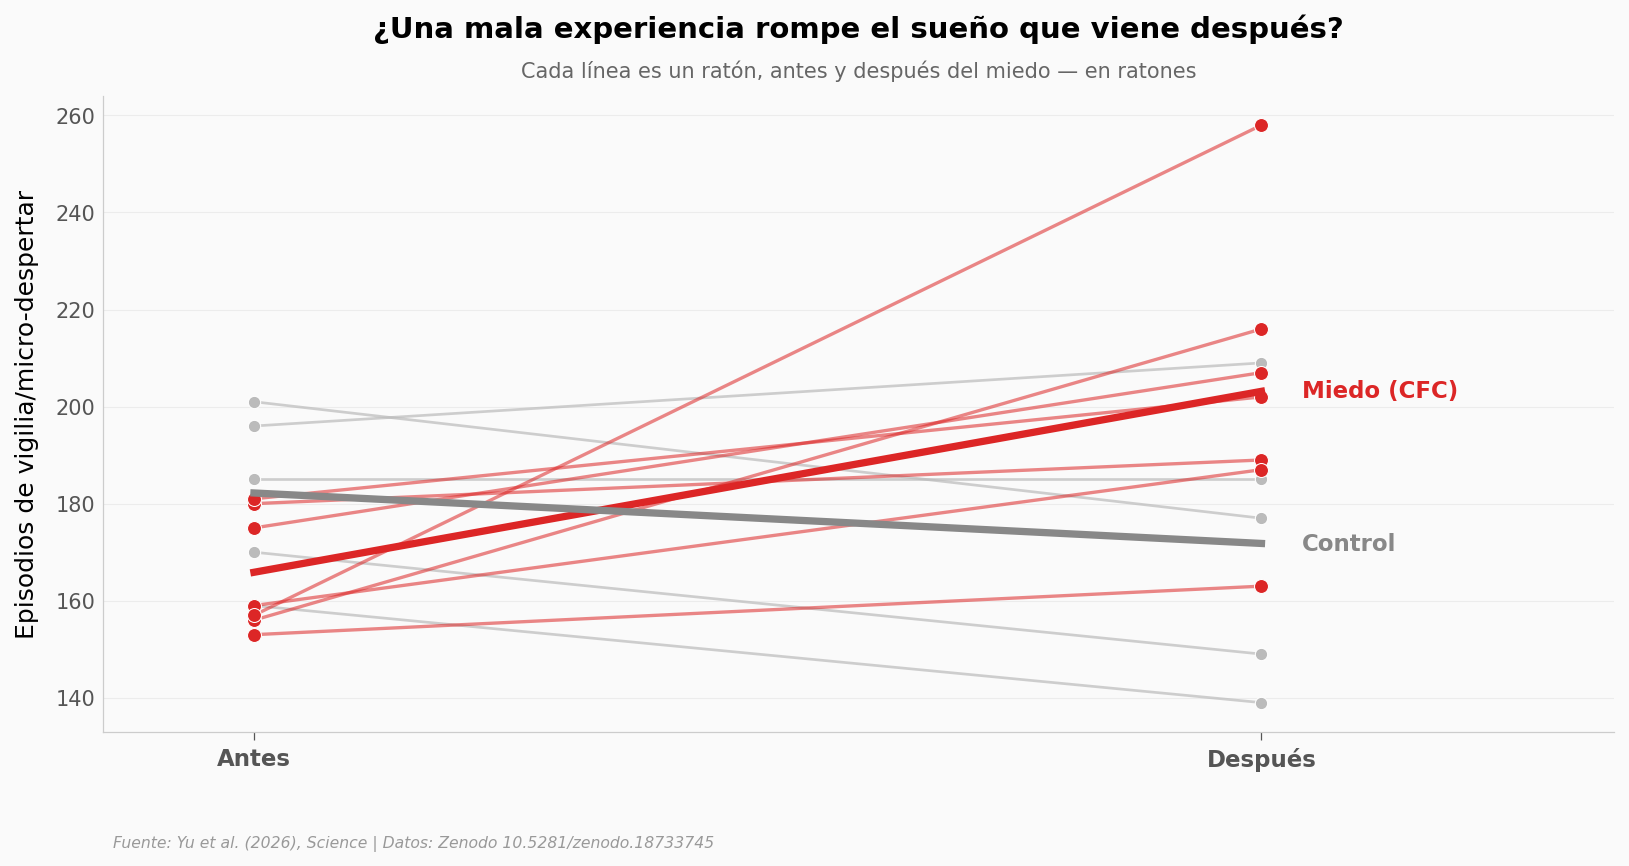

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))
x = [0, 1]

# Lineas por animal — Control (gris, fondo) y Miedo (rojo, frente)
for pre, post in zip(ctl_pre, ctl_post):
    ax.plot(x, [pre, post], color=COLOR_CONTROL, lw=1.3, alpha=0.7, zorder=2)
for pre, post in zip(cfc_pre, cfc_post):
    ax.plot(x, [pre, post], color=COLOR_MIEDO, lw=1.6, alpha=0.55, zorder=3)

# Puntos
ax.scatter([0]*len(ctl_pre), ctl_pre, color=COLOR_CONTROL, s=35, zorder=4,
           edgecolors='white', linewidths=0.5)
ax.scatter([1]*len(ctl_post), ctl_post, color=COLOR_CONTROL, s=35, zorder=4,
           edgecolors='white', linewidths=0.5)
ax.scatter([0]*len(cfc_pre), cfc_pre, color=COLOR_MIEDO, s=45, zorder=5,
           edgecolors='white', linewidths=0.5)
ax.scatter([1]*len(cfc_post), cfc_post, color=COLOR_MIEDO, s=45, zorder=5,
           edgecolors='white', linewidths=0.5)

# Lineas de promedio (gruesas)
ax.plot(x, [cfc_pre.mean(), cfc_post.mean()], color=COLOR_MIEDO, lw=3.5, zorder=6)
ax.plot(x, [ctl_pre.mean(), ctl_post.mean()], color='#888888', lw=3.5, zorder=6)

# Etiquetas inline (reemplazan legend box)
ax.text(1.04, cfc_post.mean(), 'Miedo (CFC)', color=COLOR_MIEDO,
        fontsize=11, fontweight='bold', va='center')
ax.text(1.04, ctl_post.mean(), 'Control', color='#888888',
        fontsize=11, fontweight='bold', va='center')

ax.set_xticks(x)
ax.set_xticklabels(['Antes', 'Después'], fontsize=11, fontweight='bold')
ax.set_xlim(-0.15, 1.35)
ax.set_ylabel('Episodios de vigilia/micro-despertar')
ax.set_title('¿Una mala experiencia rompe el sueño que viene después?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada línea es un ratón, antes y después del miedo — en ratones',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_slopegraph.png', dpi=200, bbox_inches='tight')
plt.show()

Cada línea es un ratón, de su noche **Antes** a su noche **Después**.

En el grupo del miedo todas suben — los **7**. En el Control las líneas se quedan planas o bajan. No es que *en promedio* el miedo fragmente el sueño: es que le pasó a **cada animal**. El cambio promedio fue de **+37 episodios** (un efecto grande: *d* pareado = 1,13), con Wilcoxon *p* = 0,016. En el Control no hubo dirección consistente (*p* = 0,25).

## ¿Se rompió todo el sueño por igual?

Esos micro-despertares interrumpen dos tipos de sueño: el **profundo** (NREM) y el **REM**, la fase donde soñamos. Si el miedo desordena el sueño entero, los dos deberían sufrir. Veamos cuál se llevó el golpe.

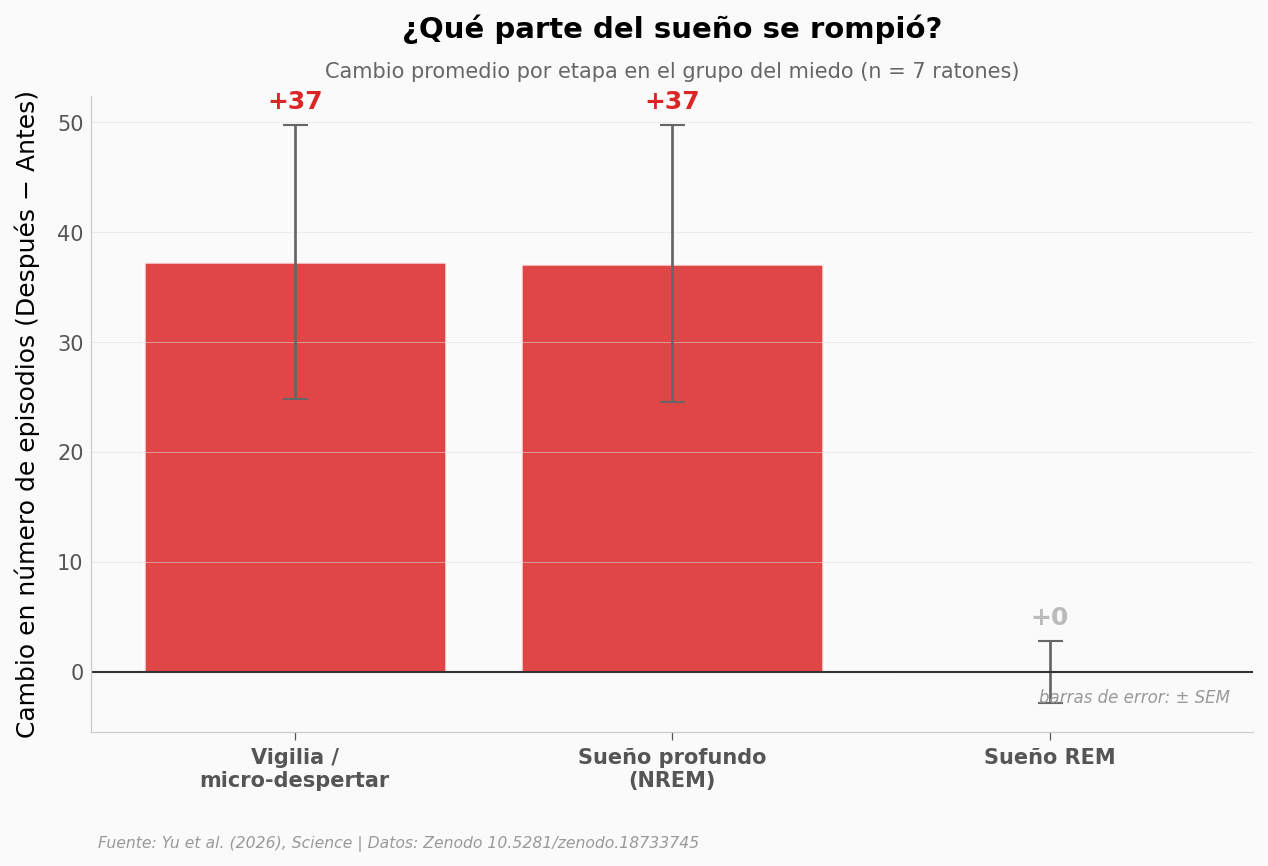

In [3]:
# Cambio promedio Después - Antes por etapa, en el grupo del miedo
etapas = ['Wake/MA', 'NREM', 'REM']
etiquetas = ['Vigilia /\nmicro-despertar', 'Sueño profundo\n(NREM)', 'Sueño REM']
medias, sems = [], []
for et in etapas:
    d = serie('CFC', 'Post', et) - serie('CFC', 'Pre', et)
    medias.append(d.mean())
    sems.append(d.std(ddof=1) / np.sqrt(len(d)))

colores = [COLOR_MIEDO, COLOR_MIEDO, COLOR_CONTROL]
fig, ax = plt.subplots(figsize=(10, 5.5))
barras = ax.bar(range(3), medias, yerr=sems, capsize=6, color=colores,
                alpha=0.85, edgecolor='white', linewidth=1.2,
                error_kw=dict(ecolor='#666666', lw=1.3))
ax.axhline(0, color='#333333', lw=1.0)

for i, (m, s) in enumerate(zip(medias, sems)):
    ax.text(i, m + s + 1.5, f'{m:+.0f}', ha='center', fontsize=12,
            fontweight='bold', color=colores[i])

ax.set_xticks(range(3))
ax.set_xticklabels(etiquetas, fontsize=10, fontweight='bold')
ax.set_ylabel('Cambio en número de episodios (Después − Antes)')
ax.set_title('¿Qué parte del sueño se rompió?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cambio promedio por etapa en el grupo del miedo (n = 7 ratones)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.04, 'barras de error: ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/cambio_por_etapa.png', dpi=200, bbox_inches='tight')
plt.show()

El **REM no se movió**: su cambio promedio es prácticamente cero (Wilcoxon *p* = 1,0). Todo el golpe está en el eje vigilia–sueño profundo: la vigilia/micro-despertar y el NREM suben casi lo mismo (**+37 episodios**), porque sus episodios se alternan a lo largo de la noche.

Dicho de otro modo: el miedo no le cambió los sueños al ratón. Multiplicó las veces que **casi se despierta**.

## ¿Qué tan anómalo es +37?

Treinta y siete episodios más. ¿Es mucho, o es el vaivén normal entre una noche y otra? La prueba más justa: poner el *cambio* de cada ratón del miedo al lado del *cambio* de cada Control.

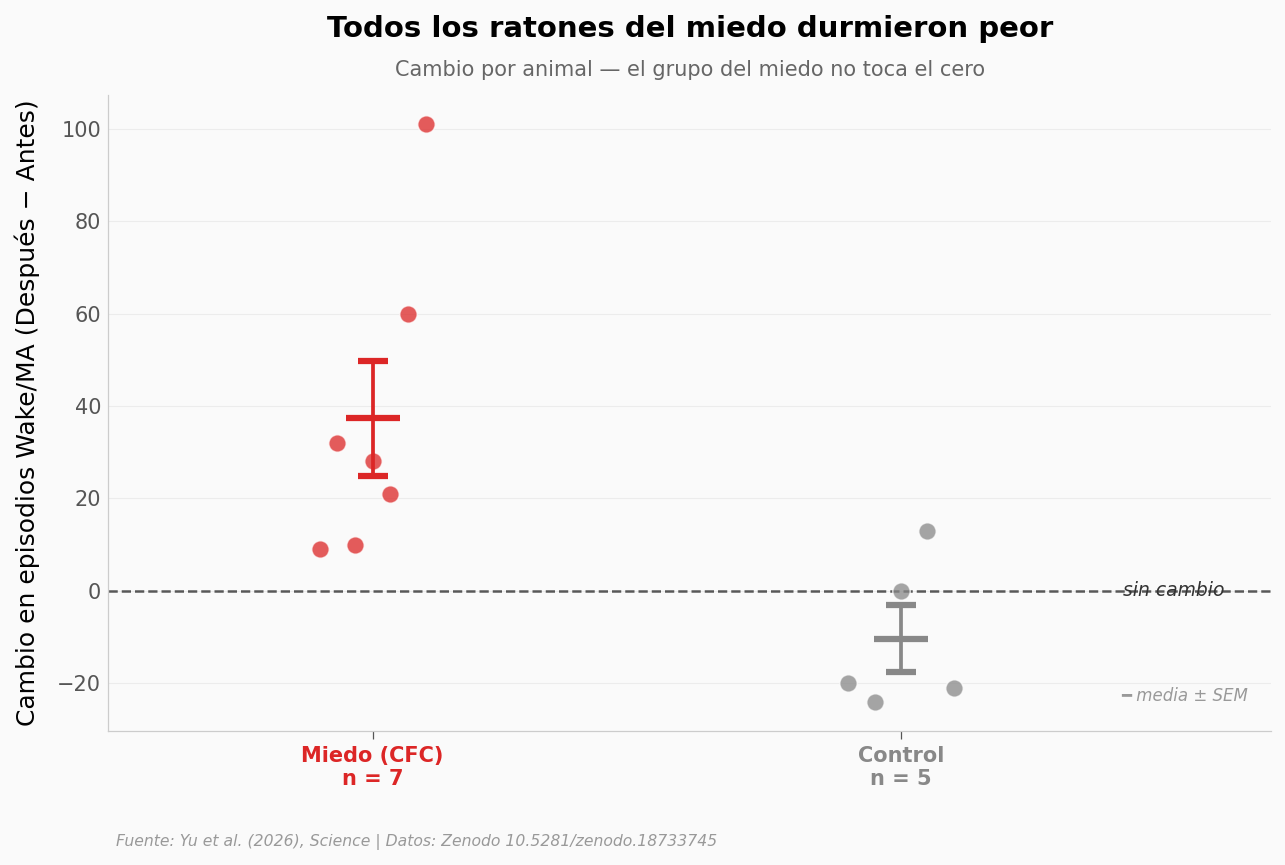

In [4]:
np.random.seed(42)
fig, ax = plt.subplots(figsize=(10, 5.5))

grupos = [('Miedo (CFC)', diffs_cfc, COLOR_MIEDO),
          ('Control', diffs_ctl, '#888888')]
posiciones = [0, 1]
for pos, (nombre, vals, color) in zip(posiciones, grupos):
    n = len(vals)
    x_strip = np.linspace(pos - 0.10, pos + 0.10, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=color, s=70, alpha=0.75,
               edgecolors='white', linewidths=0.7, zorder=5)
    media = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(pos, media, yerr=sem, fmt='_', color=color, markersize=26,
                markeredgewidth=3, capsize=7, capthick=1.6, zorder=6)

ax.axhline(0, color='#333333', lw=1.2, linestyle='--', alpha=0.8)
ax.text(1.42, 0, 'sin cambio', color='#333333', fontsize=9,
        va='center', style='italic')

ax.set_xticks(posiciones)
ax.set_xticklabels(['Miedo (CFC)\nn = 7', 'Control\nn = 5'],
                   fontsize=10, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), [COLOR_MIEDO, '#888888']):
    tick.set_color(color)
ax.set_xlim(-0.5, 1.7)
ax.set_ylabel('Cambio en episodios Wake/MA (Después − Antes)')
ax.set_title('Todos los ratones del miedo durmieron peor',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cambio por animal — el grupo del miedo no toca el cero',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.04, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/cambio_por_animal.png', dpi=200, bbox_inches='tight')
plt.show()

Los **7** ratones del miedo quedaron por encima del cero: todos durmieron más fragmentado. Los Control se reparten *alrededor* del cero — algunos un poco arriba, otros abajo, sin dirección. La nube del miedo no toca el cero; la del Control lo abraza.

Con *n* = 7 y *n* = 5 esto es una señal, no una ley. Pero es una señal limpia: el efecto INTRA-animal (cada ratón comparado consigo mismo) es lo que sostiene el hallazgo, más que la comparación entre grupos.

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El miedo fragmentó el sueño en ratones (Wake/MA +22%) | ✅ | 7/7 animales subieron · *d* pareado = 1,13 (grande) · Wilcoxon *p* = 0,016. El CFC es manipulación experimental → lenguaje causal válido. |
| El Control no cambió de forma consistente | ✅ | Δ = −5,7% · Wilcoxon *p* = 0,25 (no significativo) · solo 1/5 subió. |
| El golpe es específico: vigilia y sueño profundo, no el REM | ✅ | REM Δ ≈ 0 (*p* = 1,0). Wake/MA y NREM suben casi idéntico (+37 episodios). |
| El sueño del grupo con miedo es peor que el del Control | ⚠️ | El *cambio* Antes→Después es mayor en el grupo del miedo (Mann-Whitney *p* = 0,010; *d* = 1,74), pero con *n* = 7 vs 5 el hallazgo robusto sigue siendo el cambio dentro de cada animal (7/7 suben), no el contraste entre grupos. |

> **Limitaciones:** muestra pequeña (miedo *n* = 7, Control *n* = 5). El notebook empareja a cada ratón Antes→Después por su columna `animal_id`, pero esos identificadores se asignaron según el orden de los datos originales (que no traían un ID de animal explícito), así que el emparejamiento es una suposición razonable, no una vinculación verificada. Es un estudio en **ratones** — no se extrapola a insomnio ni a estrés postraumático humano. La continuación del paper (silenciar químicamente la reactivación de la memoria durante el sueño) no se grafica aquí: la dirección del efecto en los datos públicos quedó ambigua sin la leyenda completa de la figura.

## Ahora tú

1. **¿El sueño profundo cuenta la misma historia?** Cambia `ETAPA = 'Wake/MA'` por `'NREM'` en la celda de configuración y vuelve a correr el gráfico de líneas (el *slopegraph*). ¿Las líneas suben igual?

2. **¿Cuál ratón reaccionó más fuerte?** Mira `diffs_cfc`: los cambios van de +9 a +101 episodios. ¿Qué tan dispersa es la respuesta entre animales?

3. **¿Aguanta el efecto sin el ratón más extremo?** Quita el +101 del array y recalcula la media y el Wilcoxon. ¿Sigue siendo *p* < 0,05? (Pista abajo.)

In [5]:
# --- EXPERIMENTA AQUÍ ---
# ¿El efecto depende del ratón más extremo (+101)? Lo quitamos y recalculamos.
orden = np.argsort(diffs_cfc)            # de menor a mayor cambio
sin_extremo = orden[:-1]                 # quita el mayor (+101)

post_sin = cfc_post[sin_extremo]
pre_sin = cfc_pre[sin_extremo]
diffs_sin = post_sin - pre_sin
w_sin = stats.wilcoxon(post_sin, pre_sin)

print(f'Con los 7 ratones:   Δ medio = {diffs_cfc.mean():+.1f}  |  Wilcoxon p = {w_cfc.pvalue:.4f}')
print(f'Sin el +101 (n=6):   Δ medio = {diffs_sin.mean():+.1f}  |  Wilcoxon p = {w_sin.pvalue:.4f}')
print(f'Subieron sin extremo: {(diffs_sin>0).sum()}/{len(diffs_sin)}')
print()
print('El efecto no vive en un solo animal: aun quitando al más extremo,')
print('todos los ratones restantes siguen durmiendo más fragmentado.')

Con los 7 ratones:   Δ medio = +37.3  |  Wilcoxon p = 0.0156
Sin el +101 (n=6):   Δ medio = +26.7  |  Wilcoxon p = 0.0312
Subieron sin extremo: 6/6

El efecto no vive en un solo animal: aun quitando al más extremo,
todos los ratones restantes siguen durmiendo más fragmentado.


## Fuentes

## Fuentes

**Paper**: [Memory reactivation underlies experience-dependent adaptive regulation of sleep](https://doi.org/10.1126/science.aed8630)  
*Science, 2026-06-04*

**Datos**: [Memory Reactivation Underlies Experience-Dependent Adaptive Regulation of Sleep (source data, 26 figuras)](https://doi.org/10.5281/zenodo.18733745)

**Código del paper**: [Bolei-engram/Memory-to-sleep-code (codigo de analisis del paper)](https://github.com/Bolei-engram/Memory-to-sleep-code)

*11 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook reproducible de [Ciencia a Mordiscos](https://cienciaamordiscos.com). Código y datos: [repositorio del Lab](https://github.com/Ciencia-a-Mordiscos/lab).*